In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
X, y_true = make_blobs(n_samples=500, centers=3, cluster_std=4, random_state=42)

In [4]:
df = pd.DataFrame(X, columns=['Feature1', 'Feature2'])

In [5]:
df.head()

,Feature1,Feature2
0,-2.282534,-9.692815
1,-6.147668,1.755990
2,13.399091,-1.260023
3,-4.077630,3.160226
4,9.444735,0.340868


In [6]:
df.shape

(500, 2)

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [8]:
inertia = []
k_range = range(1,11)

In [9]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [10]:
inertia

[999.9999999999999,
 528.8064432605653,
 294.43770686781875,
 250.4552469653446,
 216.88110656982616,
 185.27440675195922,
 156.70879996290455,
 135.62603453115253,
 129.1039634823982,
 119.94101297105001]

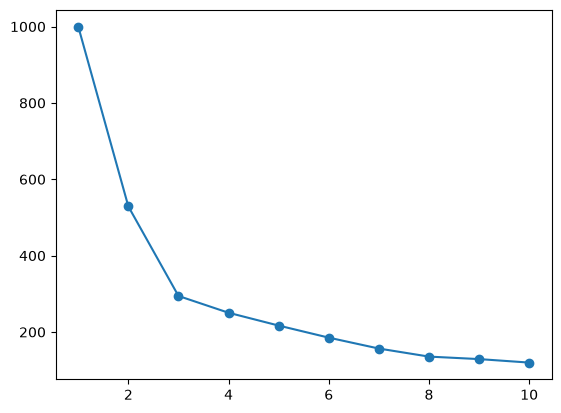

In [12]:
plt.plot(k_range, inertia, marker='o')

In [13]:
kmeans_final = KMeans(n_clusters=3, random_state=42)

In [14]:
cluster_labels = kmeans_final.fit_predict(X_scaled)

In [15]:
df['cluster'] = cluster_labels

<Axes: xlabel='Feature1', ylabel='Feature2'>

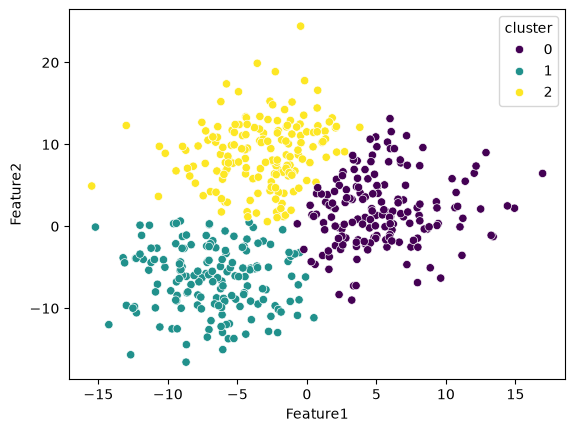

In [17]:
sns.scatterplot(x=df['Feature1'],
                y=df['Feature2'],
                hue=df['cluster'],
                palette='viridis')
     

In [18]:
from sklearn.datasets import make_moons

In [19]:
X, y_true = make_moons(n_samples=500, noise=0.05, random_state=42)

In [20]:
from sklearn.cluster import KMeans, DBSCAN

In [21]:
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [23]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [24]:
df['kmeans_cluster'] = kmeans_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

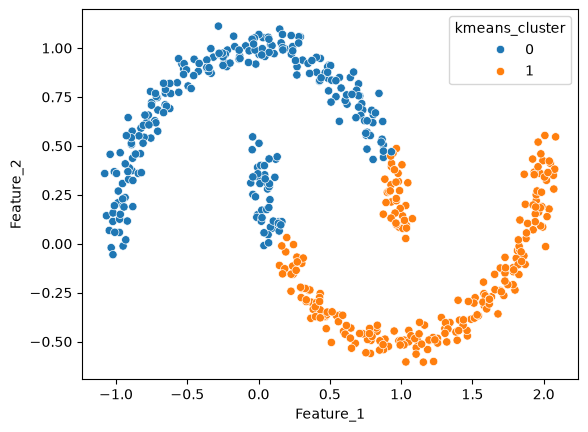

In [25]:
sns.scatterplot(x=df['Feature_1'], y=df['Feature_2'], hue=df['kmeans_cluster'], palette='tab10')

In [26]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

In [27]:
df['dbscan_cluster'] = dbscan_labels

In [28]:
df.head()

,Feature_1,Feature_2,kmeans_cluster,dbscan_cluster
0,0.830586,-0.447733,1,0
1,0.701678,0.816918,0,1
2,1.022080,-0.492571,1,0
3,-0.316765,0.953438,0,1
4,0.293226,1.057185,0,1


<Axes: xlabel='Feature_1', ylabel='Feature_2'>

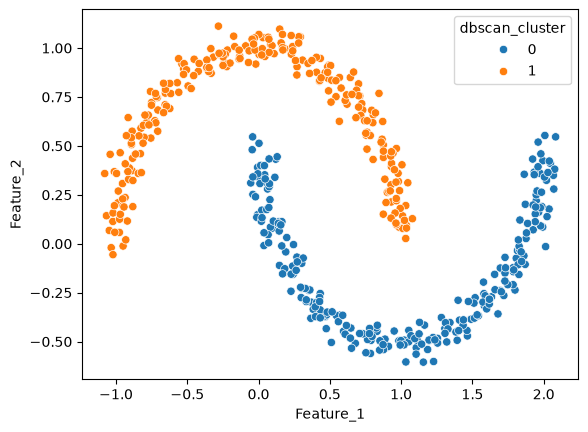

In [29]:
sns.scatterplot(x=df['Feature_1'], y=df['Feature_2'], hue=df['dbscan_cluster'], palette='tab10')